In [7]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


We want to find the $k$-dependent eigenvalues of matrix $\boldsymbol{A}(k)$. If, for a given temperature $\beta$, all eigenvalues for all $k$ are negative, the uniform distribution is stable and no clustering will occur.
The matrix depends on the pairwise interaction potential $W$ (rather, its Fourier transform).  
First, we define two functions. One computes matrix $\boldsymbol{A}$, the other one computes the spectral radii of $\boldsymbol{A}$ for a range of $\gamma$, $\beta$ and $k$ values.

In [60]:
# Matrix A(k) for given Fourier coefficient \hat{W}(k) at fixed k, beta, gamma, L. 
# We truncate it after the first "dim" rows/columns.

def A_matrix(W_hat, k, beta, gamma, L, dim):
    
    A_k = np.zeros(shape=(dim,dim),dtype=np.complex_)
    
    for i in range(dim-1):
        A_k[i][i] = i*(-gamma) 
        A_k[i][i+1] = -k*np.sqrt((i+1)/beta)*1j 
        A_k[i+1][i] = -k*np.sqrt((i+1)/beta)*1j 
    
    A_k[dim-1][dim-1] = (dim-1)*(-gamma)
    
    A_k[1][0] += -k*np.sqrt(beta)*1j*W_hat(k)/L  
    
    return A_k




# For a given number of beta and gamma values, and wavenumbers up to k_max, this function yields 
# the spectral radius of A(k) for each of them. It uses A_matrix from above.

def compute_spectral(W_hat, k_max, beta_list, gamma_list, L, dim ):

    N_beta = len(beta_list)
    N_gamma = len(gamma_list)
    
    spectral_radius = np.zeros((N_beta, N_gamma))  # Store spectral radius.
    
    print("Compute spectral radius...\n")
    
    for i in range(len(beta_list)):
        
        beta = beta_list[i]
        print(f"Testing beta {beta}.")
        
        for j in range(len(gamma_list)):
            
            gamma = gamma_list[j]
            
            # Get spectral radius for k=0.
            matrix = A_matrix(W_hat, 0, beta, gamma, L, dim)
            maximum = np.max( np.real( np.linalg.eigvals(matrix) ) ) 
            
            # Test all other wavenumbers.
            for z in range(1, k_max):
                
                k = 2*np.pi*z/L
                
                matrix = A_matrix(W_hat, k, beta, gamma, L, dim)
                
                partial_max = np.max( np.real( np.linalg.eigvals(matrix) ) )
                
                if partial_max > maximum:
                    maximum = partial_max
                
                
                # Test negative k.
                k = -k 
                matrix = A_matrix(W_hat, k, beta, gamma, L, dim)
                partial_max = np.max( np.real( np.linalg.eigvals(matrix) ) )
                
                if partial_max > maximum:
                    maximum = partial_max
            
            spectral_radius[i,j] = maximum
    
    return spectral_radius

<br>
Next, we define a plot function that will plot the results for the various potentials examined further below.


In [337]:
def plot_results(beta_list, gamma_list, spectral_radius, gamma_idx, pot_name):
    
    suptitle_fs = 20
    
    plt.rcParams['axes.titlesize'] = 15     
    plt.rcParams['axes.labelsize'] = 15     
    plt.rcParams['axes.titlepad'] = 10
    


    fig = plt.figure(figsize=(18,5))

    ### Plot spectral radius against beta at fixed gamma, given by gamma_list[gamma_idx]. ###
    ax1 = fig.add_subplot(1,3,1)
    ax1.plot(beta_list, spectral_radius[:, gamma_idx])
    ax1.set_title(f'γ={gamma_list[gamma_idx]:.4f}', )
    ax1.set_xlabel('β')
    ax1.set_ylabel(r'$\psi_{\text{max}}$')

    ### Plot spectral radius vs. (gamma, beta). ###
    ax2 = fig.add_subplot(1,3,2, projection='3d')
    X, Y = np.meshgrid(gamma_list, beta_list)
    surf = ax2.plot_surface(X, Y, spectral_radius, cmap=plt.cm.cividis)
    ax2.set_xlabel('γ')
    ax2.set_ylabel('β')
    ax2.set_zlabel(r'$\psi_{\text{max}}$', labelpad=8)
    ax2.set_title(r'$\psi_{\text{max}}$ vs. $(\gamma, \beta)$' )
    fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=10, pad=0.12)

    ### Plot time to onset of clustering for fixed gamma at last tested beta. ###
    N_particle = 1000
    t_cl = np.log(N_particle)/(2*spectral_radius[-1, :])  ## See main text.
    
    ax3 = fig.add_subplot(1,3,3)
    ax3.plot(gamma_list, t_cl)
    ax3.set_title(r'$t_{\text{cl}}$ ' + f' for {N_particle} particles,  β={beta_list[-1]:.2f}', )
    ax3.set_xlabel('γ')
    ax3.set_ylabel(r"$t_{\mathrm{cl}}$", )
    
    fig.suptitle(pot_name, size=20, y=1.01)
    
    plt.tight_layout()
    plt.show()

<br>

## Gaussian Potential 

Since we are on the torus, we may use the periodic extension of the Gaussian interaction potential, which will ease the calculation.  
The potential is given by 
$$W(r) = -\sum^{\infty}_{n=-\infty}\exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}.$$
The Fourier transform at $k=2\pi z/L$ with $z \in \mathbb{Z}$ is then given by

$$
\begin{align}
\hat{W}(k) &= \int^{L/2}_{-L/2} W(r) e^{-ik r}dr = -\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}-ikr\right)}dr, \\
           &=- \sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\left(\cos{(kr)} - i\sin{(kr)}\right)dr, \\
           &= -\sum^{\infty}_{n=-\infty}\int^{L/2}_{-L/2} \exp{\left(-\frac{\left(r+Ln\right)^{2}}{2\sigma^{2}}\right)}\cos{(kr)}dr,\\
           &= -\int^{\infty}_{-\infty} \exp{\left(-\frac{r^{2}}{2\sigma^{2}}\right)}\cos{\left(\frac{2\pi z r}{L}\right)}dr, \\
           &= -\sqrt{2\pi \sigma^2}e^{-2\sigma^{2}\pi^{2}z^{2}/L^{2}} = -\sqrt{2\pi \sigma^2} e^{-\sigma^{2}k^{2}/2}.
\end{align}
$$


An alternative is to use the non-periodic Gaussian (the one actually considered in the simulation):

$$ 
\hat{W}(k)=-\int_{-\frac{L}{2}}^{\frac{L}{2}} e^{\frac{r^2}{2\sigma^2}}e^{-ikr}dr=...=-\sqrt{\frac{\pi \sigma^2}{2}}e^{-\frac{k^2\sigma^2}{2}}\left[ erf\left( \frac{\frac{L}{2}-ik\sigma^2}{\sqrt{2\sigma^2}} \right) +erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right] = -\sqrt{2\pi\sigma^2} e^{-\frac{-k^2\sigma^2}{2}}Re\left( erf\left( \frac{\frac{L}{2}+ik\sigma^2}{\sqrt{2\sigma^2}} \right) \right).
$$

Here, $erf$ denotes the error function. Since $\frac{\sigma}{L}$ is small, the differences between the two expressions are exponentially small.

In [9]:
# Fourier transform of the Gaussian interaction.

sigma = np.sqrt(0.5)    # Width.
L = 10                  # Boxlength.

# Wrapped / periodic Gaussian.
def W_hat_gauss(k):
    W_hat_k = -np.sqrt(2*np.pi)*sigma*np.exp(-sigma**2 * k**2 /2) 
    return W_hat_k

# Non-wrapped case:
#from scipy.special import erf
#def W_hat_gauss(k):
#    W_hat_k = -np.sqrt(2*np.pi)*sigma * np.exp(-sigma**2 *k**2 /2)*np.real( erf( (0.5*L + 1j*k*sigma**2)/(np.sqrt(2*sigma**2)) ) )
#    return W_hat_k


In [355]:
# Compute spectral radius for given list of beta and gamma.

N_beta = 200
beta_list = np.linspace(1, 20, N_beta)      # Make sure grid has the correct range 
                                            # and is fine enough to pinpoint beta_c.

N_gamma = 20                                # beta_c should be independent of gamma,
gamma_list = np.linspace(0.1, 5, N_gamma)   # but it makes sense to test a few to verify this.


dim = 50    # Pick large enough such that results converge.

k_max = 50  # Pick large enough such that results converge.

spectral_radius = compute_spectral(W_hat_gauss, k_max, beta_list, gamma_list, L, dim)

Testing beta  1.0
Testing beta  1.0954773869346734
Testing beta  1.1909547738693467
Testing beta  1.2864321608040201
Testing beta  1.3819095477386933
Testing beta  1.4773869346733668
Testing beta  1.5728643216080402
Testing beta  1.6683417085427137
Testing beta  1.763819095477387
Testing beta  1.8592964824120601
Testing beta  1.9547738693467336
Testing beta  2.050251256281407
Testing beta  2.1457286432160805
Testing beta  2.241206030150754
Testing beta  2.3366834170854274
Testing beta  2.4321608040201004
Testing beta  2.527638190954774
Testing beta  2.6231155778894473
Testing beta  2.7185929648241203
Testing beta  2.8140703517587937
Testing beta  2.909547738693467
Testing beta  3.0050251256281406
Testing beta  3.100502512562814
Testing beta  3.1959798994974875
Testing beta  3.291457286432161
Testing beta  3.386934673366834
Testing beta  3.4824120603015074
Testing beta  3.577889447236181
Testing beta  3.6733668341708543
Testing beta  3.7688442211055277
Testing beta  3.8643216080402008
T

In [356]:
# Print the first beta at which eigenvalues become positive.

gamma_idx = 3 # Which gamma (columns) to consider (beta_c should be independent of it anyway).

beta_c = beta_list[ np.argmax( spectral_radius[:, gamma_idx]>0 ) ]

print("Linear stability analysis result for critical Beta: ", beta_c )


Linear stability analysis result for critical Beta:  6.251256281407035




Formula for critical beta $\beta_c$ for the Gaussian interaction by Martzel & Aslangul (2001):

$ \beta_c = \frac{L^d}{(2\pi)^{\frac{d}{2}}\sigma^d}$  

for dimensionality $d$ ($d=1$ in our case). 

In [357]:
# Print critical beta given by literature (Martzel & Aslangul, 2001).

print('Theoretical critcal beta in 1D ', L/(sigma*np.sqrt(2*np.pi)))
print('Theoretical critcal beta in 2D ', L**2/(sigma**2*2*np.pi)) 
print('Theoretical critcal beta in 3D ', L**3/(sigma**3*(2*np.pi)**(3/2)))


Theoretical critcal beta in 1D  5.6418958354775635
Theoretical critcal beta in 2D  31.83098861837906
Theoretical critcal beta in 3D  179.58712212516653


The deviations between the literature result (in 1D) and our result decrease for smaller $\frac{\sigma}{L}$ as can be easily verified be re-running the script for different values of $L$ and $\sigma$. See also Sec. REF in the supplementary material.

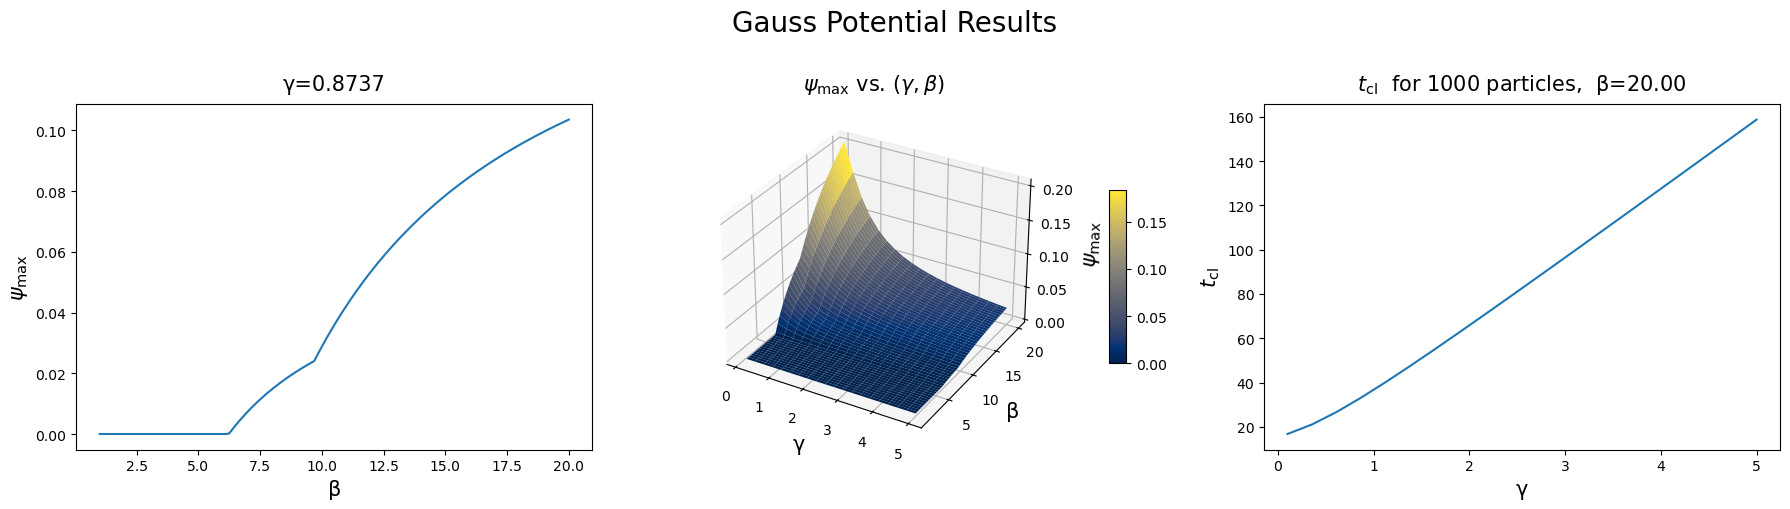

0.8736842105263158


In [358]:
plot_results(beta_list, gamma_list, spectral_radius, gamma_idx, "Gauss Potential Results")
print(gamma_list[gamma_idx])

As can be seen from the second plot, $\beta_c$ is independent of friction $\gamma$ as expected.

From the final plot, we observe an overall linear regime of $t_{\text{cl}}$ with an upward bending for $\gamma \to 0$ (which is somewhat consistent with the simulation results in the main text).

<br>

## Morse potential

The Morse potential is given by $$W(r) = D_{e}(e^{-2a(|r|-r_e)}-2e^{-a(|r|-r_e)}).$$
The Fourier transform at $k=2\pi z/L$ with $z \in \mathbb{Z}$ is then given by
$$\hat{W}(k) =  \int^{L/2}_{-L/2} W(r)\cos{(kr)}dr. $$
In contrast to the Gaussian case, we have to resort to numerical quadrature to evaluate $\hat{W}(k)$.

In [359]:
from scipy.integrate import quad

L  = 10
De = 1
re = 0
a  = 2

def integrand_morse(r, k):
    res = De * ( np.exp(-2*a*(np.abs(r)-re)) - 2*np.exp(-a*(np.abs(r)-re)) ) * np.cos(k*r)
    return res 

def W_hat_morse(k):
    W_hat_k = quad(integrand_morse, -L/2, L/2, args=(k))
    return W_hat_k[0]

In [360]:
# Compute spectral radius for given list of beta and gamma.

N_beta = 200
beta_list = np.linspace(1, 20, N_beta)     

N_gamma = 20                            
gamma_list = np.linspace(0.1, 5, N_gamma)

dim = 50    

k_max = 50  

spectral_radius = compute_spectral(W_hat_morse, k_max, beta_list, gamma_list, L, dim)

Testing beta  1.0
Testing beta  1.0954773869346734
Testing beta  1.1909547738693467
Testing beta  1.2864321608040201
Testing beta  1.3819095477386933
Testing beta  1.4773869346733668
Testing beta  1.5728643216080402
Testing beta  1.6683417085427137
Testing beta  1.763819095477387
Testing beta  1.8592964824120601
Testing beta  1.9547738693467336
Testing beta  2.050251256281407
Testing beta  2.1457286432160805
Testing beta  2.241206030150754
Testing beta  2.3366834170854274
Testing beta  2.4321608040201004
Testing beta  2.527638190954774
Testing beta  2.6231155778894473
Testing beta  2.7185929648241203
Testing beta  2.8140703517587937
Testing beta  2.909547738693467
Testing beta  3.0050251256281406
Testing beta  3.100502512562814
Testing beta  3.1959798994974875
Testing beta  3.291457286432161
Testing beta  3.386934673366834
Testing beta  3.4824120603015074
Testing beta  3.577889447236181
Testing beta  3.6733668341708543
Testing beta  3.7688442211055277
Testing beta  3.8643216080402008
T

In [363]:
# Print the first beta at which eigenvalues become positive.

gamma_idx = 3 # Which gamma (columns) to consider (beta_c should be independent of it anyway).

beta_c = beta_list[ np.argmax( spectral_radius[:, gamma_idx]>0 ) ]

print("Linear stability analysis result for critical Beta: ", beta_c )

Linear stability analysis result for critical Beta:  7.5879396984924625


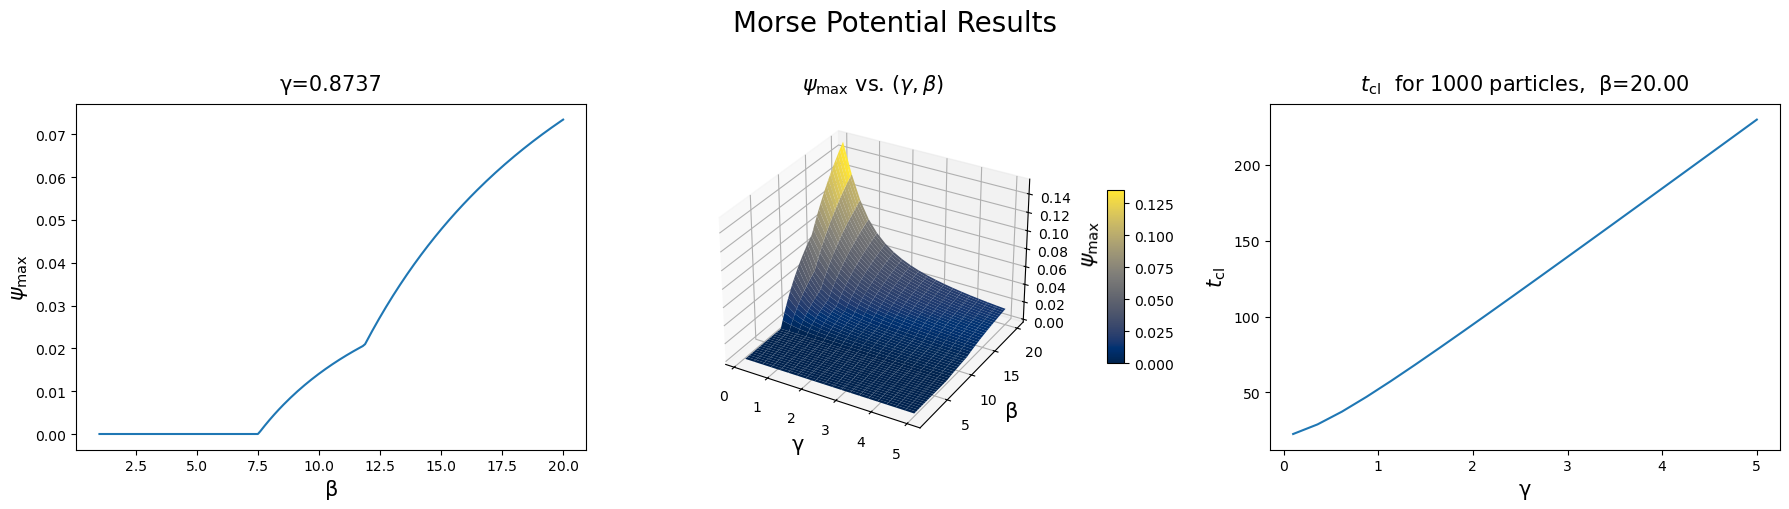

In [364]:
plot_results(beta_list, gamma_list, spectral_radius, gamma_idx, "Morse Potential Results")

## GEM-$\alpha$

The GEM-$\alpha$ potential is given by 
$$W(r) = -e^{-\Big(\frac{\|r\|}{\sqrt{2\sigma^2}}\Big)^\alpha}.$$
The Fourier transform at $k=2\pi z/L$ with $z \in \mathbb{Z}$ is then given by
$$\hat{W}(k) =  \int^{L/2}_{-L/2} W(r)\cos{(kr)}dr, $$
and we use numerical quadrature again to evaluate it.

In [365]:
from scipy.integrate import quad

L  = 10
sigma = np.sqrt(0.5)
alpha  = 4.0

def integrand_GEM(r, k):
    res = -np.exp( -( np.abs(r)/np.sqrt(2*(sigma**2)) )**alpha ) * np.cos(k*r)
    return res 


def W_hat_GEM(k):
    W_hat_k = quad(integrand_GEM, -L/2, L/2, args = (k,))
    return W_hat_k[0]


In [366]:
# Compute spectral radius for given list of beta and gamma.

N_beta = 200
beta_list = np.linspace(1, 20, N_beta)     

N_gamma = 20                            
gamma_list = np.linspace(0.1, 5, N_gamma)

dim = 50    

k_max = 50  

spectral_radius = compute_spectral(W_hat_GEM, k_max, beta_list, gamma_list, L, dim)

Testing beta  1.0
Testing beta  1.0954773869346734
Testing beta  1.1909547738693467
Testing beta  1.2864321608040201
Testing beta  1.3819095477386933
Testing beta  1.4773869346733668
Testing beta  1.5728643216080402
Testing beta  1.6683417085427137
Testing beta  1.763819095477387
Testing beta  1.8592964824120601
Testing beta  1.9547738693467336
Testing beta  2.050251256281407
Testing beta  2.1457286432160805
Testing beta  2.241206030150754
Testing beta  2.3366834170854274
Testing beta  2.4321608040201004
Testing beta  2.527638190954774
Testing beta  2.6231155778894473
Testing beta  2.7185929648241203
Testing beta  2.8140703517587937
Testing beta  2.909547738693467
Testing beta  3.0050251256281406
Testing beta  3.100502512562814
Testing beta  3.1959798994974875
Testing beta  3.291457286432161
Testing beta  3.386934673366834
Testing beta  3.4824120603015074
Testing beta  3.577889447236181
Testing beta  3.6733668341708543
Testing beta  3.7688442211055277
Testing beta  3.8643216080402008
T

In [369]:
# Print the first beta at which eigenvalues become positive.

gamma_idx = 3 # Which gamma (columns) to consider (beta_c should be independent of it anyway).

beta_c = beta_list[ np.argmax( spectral_radius[:, gamma_idx]>0 ) ]

print("Linear stability analysis result for critical Beta: ", beta_c )

Linear stability analysis result for critical Beta:  5.964824120603015


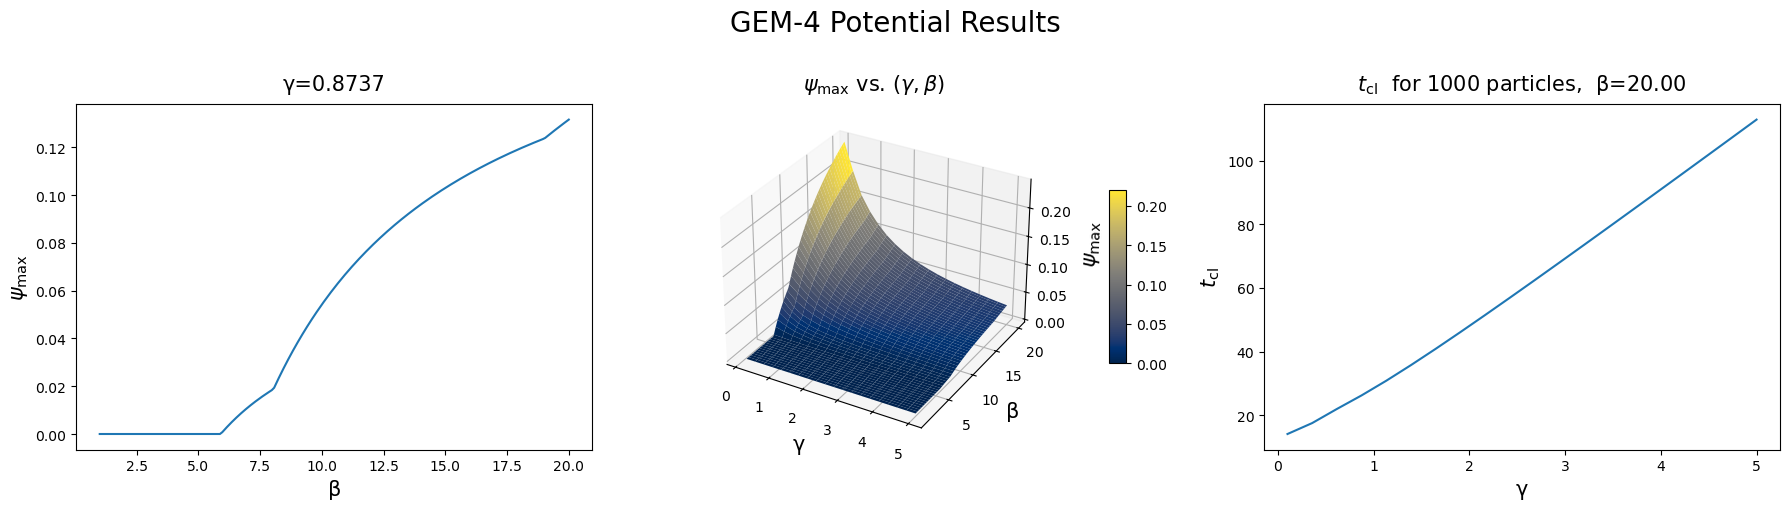

In [370]:

plot_results(beta_list, gamma_list, spectral_radius, gamma_idx, "GEM-4 Potential Results")

# Fluctuation Analysis
We want to compute the spatial correlation of the density fluctuation $\rho_1$, i.e., $\mathbb{E}(\rho_1(t,x,v)\rho_1(t,x',v))$ at different times $t$. 
For that aim, we compute the Fourier modes $\mathbb{E}(c(k,t))$ (see the main text for their expression) and recover the spatial signal via inverse Fourier analysis. First, we define functions to compute $\mathbb{E}(c(k,t))$ on a list of wavenumbers $k=\pm \frac{2\pi n}{L}$, $n\in \mathbb{R}$.


In [69]:
from scipy.linalg import expm
from scipy.integrate import quad

"""
Integrand in formula for E( ||c(k,t)||^2 ).
"""
def integrand(s, t, A):
        
    exp_A = expm((t-s)*A)  # Matrix exponential.
    
    n, m = exp_A.shape
    D = np.diag(np.arange(0, m)) 
    
    M = exp_A @ D
    
    trace_M_MT = np.trace( M @ (M.conj().T) )  # Trace to be integrated over.
    
    return trace_M_MT
    


"""
Obtain E( ||c(k,t)||^2 ).
"""
def get_fourier_coefficient(k, t, L, dim, beta, gamma, W_hat):
    
    # Obtain matrix A.
    A = A_matrix(W_hat, k, beta, gamma, L, dim)
    
    # Compute the two terms of the sum.
    Term1 = np.trace( expm(t * A) @ expm(t * A.conj().T) )  

    integral = quad(integrand, 0, t, args=(t, A), limit=200)[0]
    Term2 = 8*gamma*integral
    
    mean_ck_sq = np.real(Term1 + Term2)  # E( ||c(k,t)||^2 ).
    
    return mean_ck_sq




"""
For a given list of wavenumbers k, obtain Fourier coefficients E( ||c(k,t)||^2 ).
"""
def get_fourier_coefficient_list(k_list, t, L, dim, beta, gamma, W_hat):
    
    out = []
    
    for k in k_list:
        mean_ck_sq = get_fourier_coefficient(k, t, L, dim, beta, gamma, W_hat)
        out += [mean_ck_sq]
    
    return np.array(out)


Next we define a plotting function that takes the Fourier coefficients obtained from the functions above and plots the inverse Fourier transform against $x-x'$ at time $t$.

In [70]:
def plot_fluctuation_real_space(f_hat, t):
    
    N = len(f_hat)
    
    # Inverse FFT to get f(x) in physical space.
    f_x = np.fft.ifft(np.fft.ifftshift(f_hat))  # Shift to match fftfreq order.
    f_x = np.fft.fftshift(f_x)                  # Shift back for plotting.
    f_x *= N                                    # Normalization.

    x = np.linspace(-L/2, L/2, N, endpoint=False) # Space to plot against.

    # Estimate amplitude of fluctuation by cropping Dirac out.
    AMPL = np.max(np.real( f_x[:int(0.45*np.size(f_x))] ))
    ylims = [-2*AMPL, 2*AMPL]
    
    
    plt.figure(figsize=(10, 4))


    plt.ylim(ylims)
    plt.plot(x, np.real(f_x), label="Real part")
    plt.plot(x, np.imag(f_x), '--', label="Imaginary part")
    plt.title("$t$ = "+str(t))
    plt.xlabel("$x-x'$")
    plt.ylabel("$\mathbb{E}(ρ_{1}(t,x) ρ_{1}(t,x'))$")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_805892/3700843229.py:25: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("$\mathbb{E}(ρ_{1}(t,x) ρ_{1}(t,x'))$")


<br>
We now consider the Gaussian interaction potential as an example again and plot $\mathbb{E}(\rho_1(t,x,v)\rho_1(t,x',v))$ for different times $t$ at some $\beta > \beta_c$.

In [71]:
# Parameters.
N = 512       # Number of Fourier modes to consider.
dim = 25      # Number of rows/cols of matrix A to consider.
gamma = 1.0
beta = 25
W_hat = W_hat_gauss  # Fourier transform of Gauss interaction (see previous section).


k_list = 2 * np.pi * np.fft.fftfreq(N, d=L / N) # List of wavenumbers to consider.



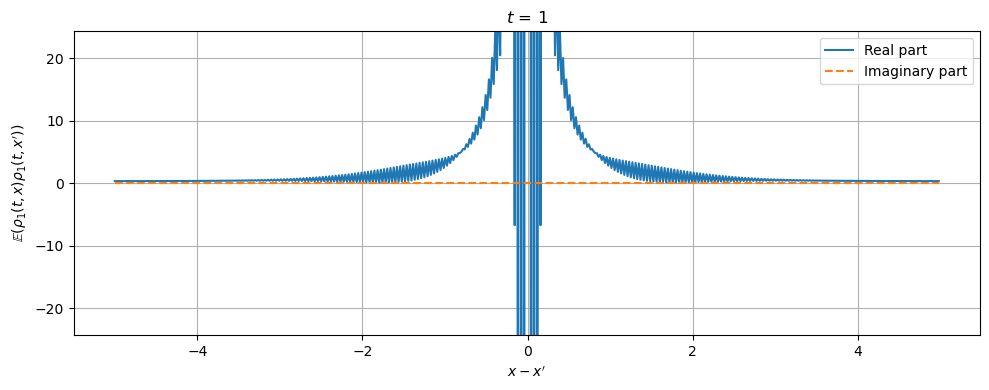

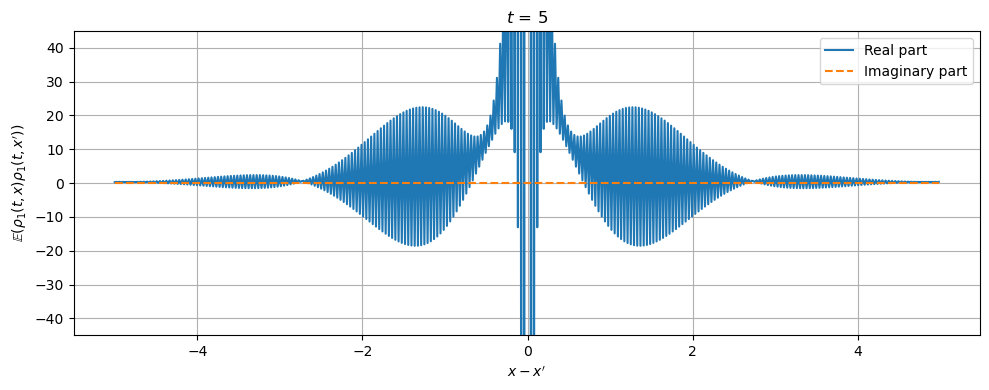

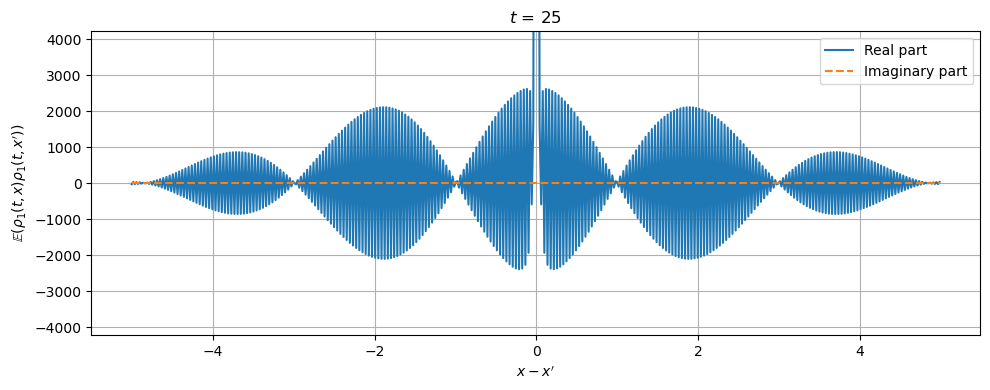

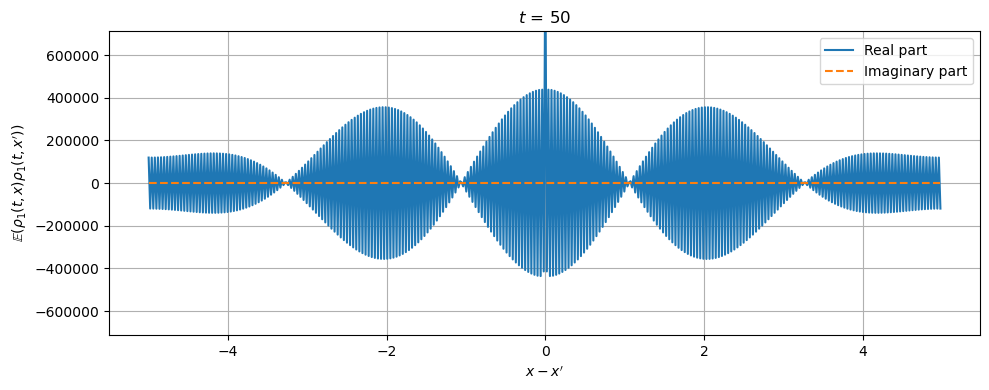

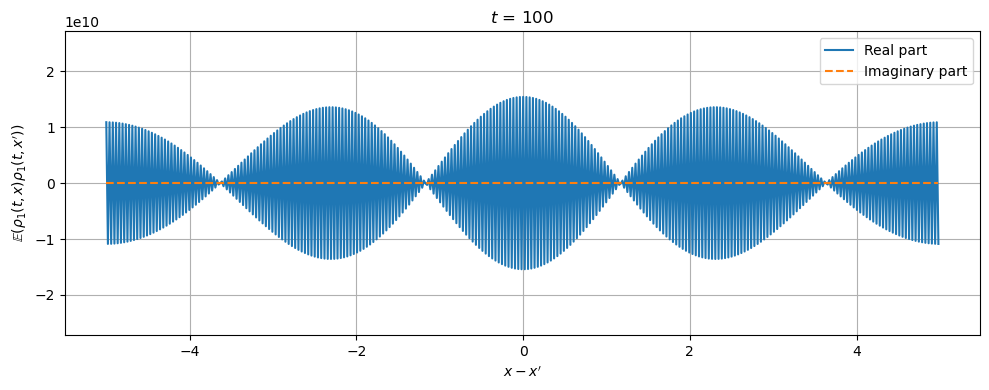

In [72]:
## Time t=1.
t = 1    

f_hat = get_fourier_coefficient_list(k_list, t, L, dim, beta, gamma, W_hat)  # Get E(||c(k,t)||^2) for each k.

plot_fluctuation_real_space(f_hat, t) # Plot results in real space.



## Time t=5.
t = 5   

f_hat = get_fourier_coefficient_list(k_list, t, L, dim, beta, gamma, W_hat)  
plot_fluctuation_real_space(f_hat, t) 


## Time t=25.
t = 25   

f_hat = get_fourier_coefficient_list(k_list, t, L, dim, beta, gamma, W_hat)  
plot_fluctuation_real_space(f_hat, t) 


## Time t=50.
t = 50  

f_hat = get_fourier_coefficient_list(k_list, t, L, dim, beta, gamma, W_hat)  
plot_fluctuation_real_space(f_hat, t) 


## Time t=100.
t = 100  

f_hat = get_fourier_coefficient_list(k_list, t, L, dim, beta, gamma, W_hat)  
plot_fluctuation_real_space(f_hat, t) 

We observe that the amplitude of the spatial autocorrelation of $\rho_1$ becomes cosine-modulated and exponentially larger with progressing time.
<br>
Next, we examine the growth of the amplitude with time $t$. For that aim, we first define a function that collects these amplitudes at a list of time values.

In [73]:
def AMP_lists(k_list, t_list, L, dim, beta, gamma, W_hat):  
    
    print("Computing fluctuation amplitudes at different times...\n")
    
    AMP_list = []
    
    for t in t_list:
    
        print(f"t={t}\n")
        f_hat = get_fourier_coefficient_list(k_list, t, L, dim, beta, gamma, W_hat)  
            
        f_x = np.fft.ifft(np.fft.ifftshift(f_hat))  # Shift to match fftfreq order.
        f_x = f_x * N 
        f_x = np.fft.fftshift(f_x)


        # Amplitude := Maximum of first 45% of values (see text below).
        AMPL = np.max(np.real(f_x[:int(0.45*np.size(f_x))]))
        AMP_list.append(AMPL)
        
    return AMP_list
    

Since for small times $t$ there is no well defined amplitude as the Dirac-Peak is still decaying, we heuristically estimated "the amplitude" to be the maximum value of $\mathbb{E}(\rho_1(t,x,v)\rho_1(t,x',v))$ outside of a small region around $x-x'=0$, which crops out the Dirac part.

<br>
Next, we run this function for three different friction values $\gamma$ and plot the results together with the curve $e^{2\psi_{\text{max}}t}$, with $\psi_{\text{max}}$ the spectral radius of matrix $A$.


In [ ]:

beta = 25

eps = 0.1
t_list = np.linspace(eps, 100, 20)

gammas = [1.0, 0.1, 0.01] 
amp_list = []
expo_psi_max_list = []

for gamma in gammas:
    print(f"\nGamma = {gamma}.")

    amp_list += [AMP_lists(k_list, t_list, L, dim, beta, gamma, W_hat)]

    # Spectral radius of A at given gamma, beta (see first half of notebook).
    psi_max = compute_spectral(W_hat_gauss, int(len(k_list)/2), [beta], [gamma], L, dim )[0][0]
    expo_psi_max_list += [np.exp(2*psi_max*t_list)]



Gamma = 1.0.
Computing fluctuation amplitudes at different times...

t=0.1

t=5.3578947368421055

t=10.615789473684211

t=15.873684210526317



<>:18: SyntaxWarning: invalid escape sequence '\g'
<>:18: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_805892/2205852979.py:18: SyntaxWarning: invalid escape sequence '\g'
  ax.set_title('$β =$'+str(beta)+', $\gamma =$'+str(gamma))


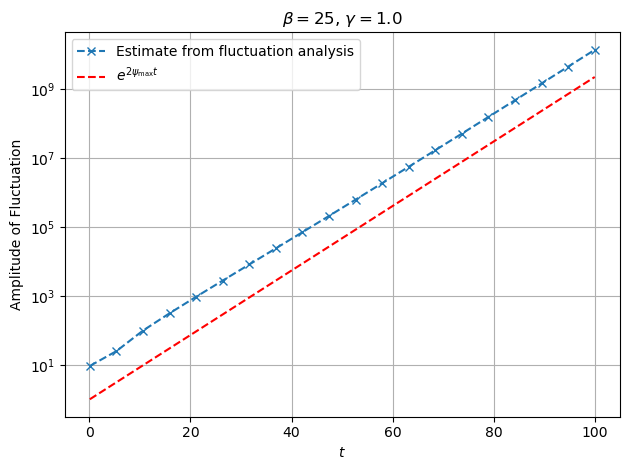

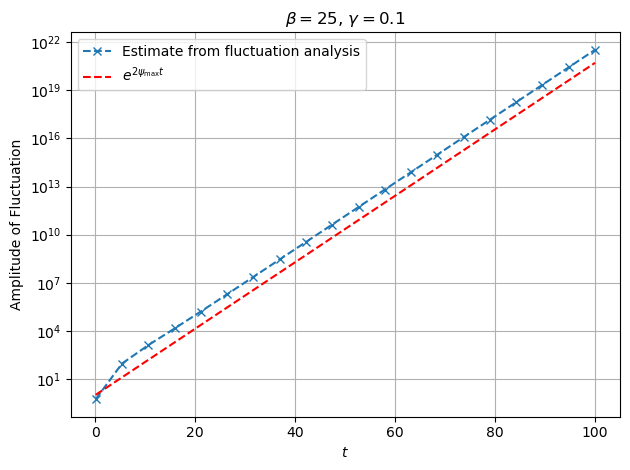

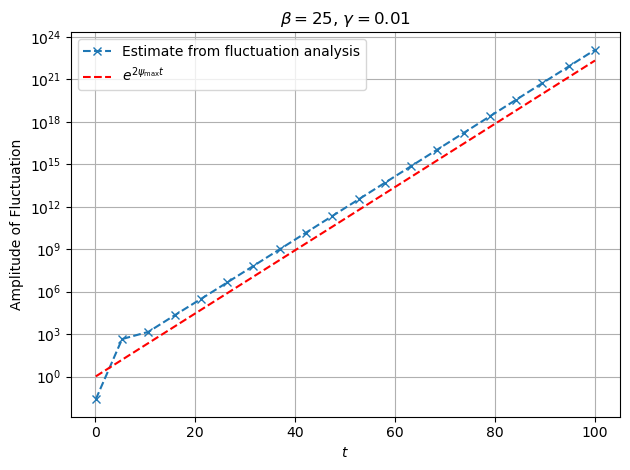

In [66]:
# Plot results.

for (gamma, amp, expo_psi_max) in zip(gammas, amp_list, expo_psi_max_list):
    
    fig, ax = plt.subplots()

    # Plot original data.
    ax.semilogy(t_list, amp, 'x--', label='Estimate from fluctuation analysis')

    # Plot best-fit line.
    ax.semilogy(t_list, expo_psi_max, 'r--', label=fr'$e^{{2 \psi_{{\max}} t}}$')


    ax.grid()
    ax.legend()
    ax.set_xlabel('$t$')
    ax.set_ylabel('Amplitude of Fluctuation')
    ax.set_title('$β =$'+str(beta)+', $\gamma =$'+str(gamma))
    fig.tight_layout()
    plt.show()

The plots clearly show that the fluctuation amplitudes obtained from the linear stability analysis qualitatively align with $e^{2\psi_{\text{max}}t}$, which can then be used to derive an expression for the time to the onset of clustering (see main text).